In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
df = pd.read_csv(r"C:\Users\Asus\Desktop\B6G2-08_AI_ML_PROJECT-main\B6G2-08_AI_ML_PROJECT-main\data\raw\warsaw.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (10954, 11)
       STATION        NAME  LATITUDE  LONGITUDE  ELEVATION        DATE  PRCP  \
0  PLM00012375  OKECIE, PL    52.166     20.967      110.3  1993-01-01   0.0   
1  PLM00012375  OKECIE, PL    52.166     20.967      110.3  1993-01-02   NaN   
2  PLM00012375  OKECIE, PL    52.166     20.967      110.3  1993-01-03   0.0   
3  PLM00012375  OKECIE, PL    52.166     20.967      110.3  1993-01-04   0.0   
4  PLM00012375  OKECIE, PL    52.166     20.967      110.3  1993-01-05   0.0   

   SNWD  TAVG  TMAX  TMIN  
0  10.0  -8.3   NaN   NaN  
1  10.0 -14.9   NaN   NaN  
2  10.0 -13.6  -9.7   NaN  
3  10.0 -10.5  -6.5 -13.3  
4  10.0 -12.0  -8.9 -14.1  


In [42]:
df.columns

Index(['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE', 'PRCP',
       'SNWD', 'TAVG', 'TMAX', 'TMIN', 'PRCP_log'],
      dtype='object')

In [43]:
# Convert DATE to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Create season
df['Season'] = df['DATE'].dt.month.map({
    12: 'Winter',
    1: 'Winter',
    2: 'Winter',
    3: 'Spring',
    4: 'Spring',
    5: 'Spring',
    6: 'Summer',
    7: 'Summer',
    8: 'Summer',
    9: 'Autumn',
    10: 'Autumn',
    11: 'Autumn'
})

# Convert Season into 4 columns
season_dummies = pd.get_dummies(
    df['Season'],
    prefix='Season',
    dtype=int
)

df = pd.concat([df, season_dummies], axis=1)

print(df.columns)

Index(['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE', 'PRCP',
       'SNWD', 'TAVG', 'TMAX', 'TMIN', 'PRCP_log', 'Season', 'Season_Autumn',
       'Season_Spring', 'Season_Summer', 'Season_Winter'],
      dtype='object')


In [47]:
print("\n====================================")
print("MULTIPLE LINEAR REGRESSION - TAVG")
print("====================================")

# Keep only required columns and remove missing values
temp_data = df[
    [
        "SNWD",
        "TMIN",
        "PRCP_log",
        "Season_Autumn",
        "Season_Spring",
        "Season_Summer",
        "Season_Winter",
        "TAVG"
    ]
].dropna()

# Features
X_temp = temp_data[
    [
        "SNWD",
        "TMIN",
        "PRCP_log",
        "Season_Autumn",
        "Season_Spring",
        "Season_Summer",
        "Season_Winter"
    ]
]

# Target
y_temp = temp_data["TAVG"]

print("Features:")
print(X_temp.columns.tolist())

print("\nTarget:")
print(y_temp.name)

print("\nRows after removing NaN:", len(temp_data))
print("NaN values:", X_temp.isna().sum().sum())


MULTIPLE LINEAR REGRESSION - TAVG
Features:
['SNWD', 'TMIN', 'PRCP_log', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']

Target:
TAVG

Rows after removing NaN: 643
NaN values: 0


In [48]:
from sklearn.model_selection import train_test_split

X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train_temp.shape)
print("Testing data shape:", X_test_temp.shape)

Training data shape: (514, 7)
Testing data shape: (129, 7)


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

# Create Multiple Linear Regression model
temp_model = LinearRegression()

# Parameters to tune
param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

# Grid Search with 5-fold Cross Validation
grid_temp = GridSearchCV(
    estimator=temp_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

# Train and tune the model
grid_temp.fit(X_train_temp, y_train_temp)

print("Best Parameters:", grid_temp.best_params_)
print("Best Cross-Validation R²:", grid_temp.best_score_)

Best Parameters: {'fit_intercept': True, 'positive': True}
Best Cross-Validation R²: 0.8705789226696767


In [50]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Get the best model
best_temp_model = grid_temp.best_estimator_

# Make predictions
y_pred_temp = best_temp_model.predict(X_test_temp)

# Calculate evaluation metrics
temp_r2 = r2_score(y_test_temp, y_pred_temp)
temp_rmse = np.sqrt(mean_squared_error(y_test_temp, y_pred_temp))

print("\n====================================")
print("TAVG FINAL EVALUATION")
print("====================================")
print("R²   :", temp_r2)
print("RMSE :", temp_rmse)


TAVG FINAL EVALUATION
R²   : 0.8624976446876125
RMSE : 1.6397819597014627


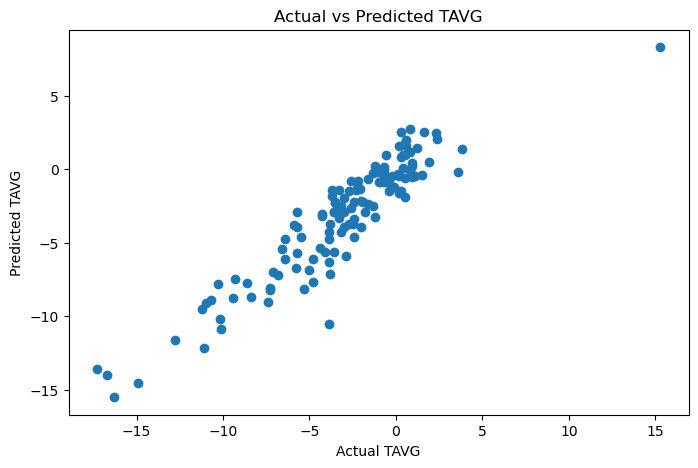

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test_temp, y_pred_temp)
plt.xlabel("Actual TAVG")
plt.ylabel("Predicted TAVG")
plt.title("Actual vs Predicted TAVG")
plt.show()